# RobotEmotions Dataset Distribution per Class

This notebook explores the class distribution of the local `RobotEmotions` dataset using the same scan logic implemented in `pose_module.robot_emotions.extractor.RobotEmotionsExtractor`.

The three protocol label types come from [metadata.py](../pose_module/robot_emotions/metadata.py):
- `emotion`
- `modality`
- `stimulus`

The investigation focuses on:
- overall class balance
- per-domain differences between `10ms` and `30ms`
- co-occurrence patterns between the label types
- protocol tags defined in metadata versus clips actually present on disk

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / "pose_module").exists() and (candidate / "evaluation").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Project root not found. Open the notebook inside the IMUGPT repository.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from pose_module.robot_emotions.extractor import RobotEmotionsExtractor
from pose_module.robot_emotions.metadata import PROTOCOL_ROWS

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

DATASET_ROOT = PROJECT_ROOT / "data" / "RobotEmotions"
LABEL_COLUMNS = ("emotion", "modality", "stimulus")

extractor = RobotEmotionsExtractor(DATASET_ROOT)
print(f"Dataset root: {DATASET_ROOT}")

Dataset root: /home/henriquesouza/IMUGPT/data/RobotEmotions


In [2]:
records = extractor.scan()
if not records:
    raise RuntimeError(f"No RobotEmotions clips found under {DATASET_ROOT}")

rows = []
for record in records:
    protocol = record.protocol or {}
    rows.append(
        {
            "clip_id": record.clip_id,
            "domain": record.domain,
            "user_id": record.user_id,
            "tag_number": record.tag_number,
            "take_id": record.take_id,
            "source_rel_dir": record.source_rel_dir,
            "emotion": protocol.get("emotion"),
            "modality": protocol.get("modality"),
            "stimulus": protocol.get("stimulus"),
        }
    )

clips_df = pd.DataFrame(rows).sort_values(
    ["domain", "user_id", "tag_number", "clip_id"],
    kind="stable",
).reset_index(drop=True)

clips_df.head(10)

,clip_id,domain,user_id,tag_number,take_id,source_rel_dir,emotion,modality,stimulus
0,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,10ms/User2/Tag1,Neutrality,Standing,None
1,robot_emotions_10ms_u02_tag05,10ms,2,5,NaN,10ms/User2/Tag5,Sadness,Sitting,Visual methods
2,robot_emotions_10ms_u02_tag06,10ms,2,6,NaN,10ms/User2/Tag6,Sadness,Sitting,Autobiographical recall
3,robot_emotions_10ms_u02_tag07,10ms,2,7,NaN,10ms/User2/Tag7,Sadness,Standing,Autobiographical recall
4,robot_emotions_10ms_u02_tag09,10ms,2,9,NaN,10ms/User2/Tag9,Happiness,Sitting,Visual methods
5,robot_emotions_10ms_u02_tag10,10ms,2,10,NaN,10ms/User2/Tag10,Happiness,Sitting,Autobiographical recall
6,robot_emotions_10ms_u02_tag11,10ms,2,11,NaN,10ms/User2/Tag11,Happiness,Standing,Autobiographical recall
7,robot_emotions_10ms_u02_tag16,10ms,2,16,NaN,10ms/User2/Tag16,Boredom,Sitting,Visual methods
8,robot_emotions_10ms_u02_tag17,10ms,2,17,NaN,10ms/User2/Tag17,Boredom,Standing,Visual methods
9,robot_emotions_10ms_u02_tag18,10ms,2,18,NaN,10ms/User2/Tag18,Curiosity,Standing,Simulation


In [3]:
def distribution_table(frame: pd.DataFrame, label: str) -> pd.DataFrame:
    counts = frame[label].fillna("Unknown").value_counts(dropna=False).rename_axis(label).reset_index(name="count")
    counts["pct"] = counts["count"] / len(frame)
    counts["pct"] = counts["pct"].map(lambda value: round(float(value) * 100.0, 2))
    return counts


def add_value_labels(ax: plt.Axes) -> None:
    for patch in ax.patches:
        width = patch.get_width()
        height = patch.get_height()
        if np.isnan(width) or np.isnan(height):
            continue
        if width >= height:
            ax.text(width + 0.15, patch.get_y() + height / 2.0, f"{int(round(width))}", va="center", fontsize=9)
        else:
            ax.text(patch.get_x() + width / 2.0, height + 0.15, f"{int(round(height))}", ha="center", fontsize=9)


repeat_groups = (
    clips_df.groupby(["domain", "user_id", "tag_number"]).size().rename("num_clips").reset_index()
)
repeat_groups = repeat_groups[repeat_groups["num_clips"] > 1].sort_values(
    ["domain", "user_id", "tag_number"],
    kind="stable",
)

summary = pd.Series(
    {
        "num_clips": int(len(clips_df)),
        "num_domains": int(clips_df["domain"].nunique()),
        "num_domain_user_pairs": int(clips_df[["domain", "user_id"]].drop_duplicates().shape[0]),
        "num_observed_domain_tag_pairs": int(clips_df[["domain", "tag_number"]].drop_duplicates().shape[0]),
        "clips_with_repeat_take_id": int(clips_df["take_id"].notna().sum()),
        "num_repeated_domain_user_tag_groups": int(len(repeat_groups)),
    },
    name="value",
)

summary.to_frame()

,value
num_clips,89
num_domains,2
num_domain_user_pairs,11
num_observed_domain_tag_pairs,24
clips_with_repeat_take_id,2
num_repeated_domain_user_tag_groups,1


## Overall Distribution

These tables and plots answer the simplest question first: how many clips belong to each class, regardless of domain.

In [4]:
overall_distribution = pd.concat(
    {label: distribution_table(clips_df, label) for label in LABEL_COLUMNS},
    names=["label_type"],
).reset_index(level=0)

overall_distribution

,label_type,emotion,count,pct,modality,stimulus
0,emotion,Sadness,23,25.84,NaN,NaN
1,emotion,Happiness,22,24.72,NaN,NaN
2,emotion,Neutrality,19,21.35,NaN,NaN
3,emotion,Boredom,14,15.73,NaN,NaN
4,emotion,Curiosity,7,7.87,NaN,NaN
5,emotion,Fear,3,3.37,NaN,NaN
6,emotion,Anger,1,1.12,NaN,NaN
0,modality,NaN,54,60.67,Sitting,NaN
1,modality,NaN,35,39.33,Standing,NaN
0,stimulus,NaN,31,34.83,NaN,Visual methods


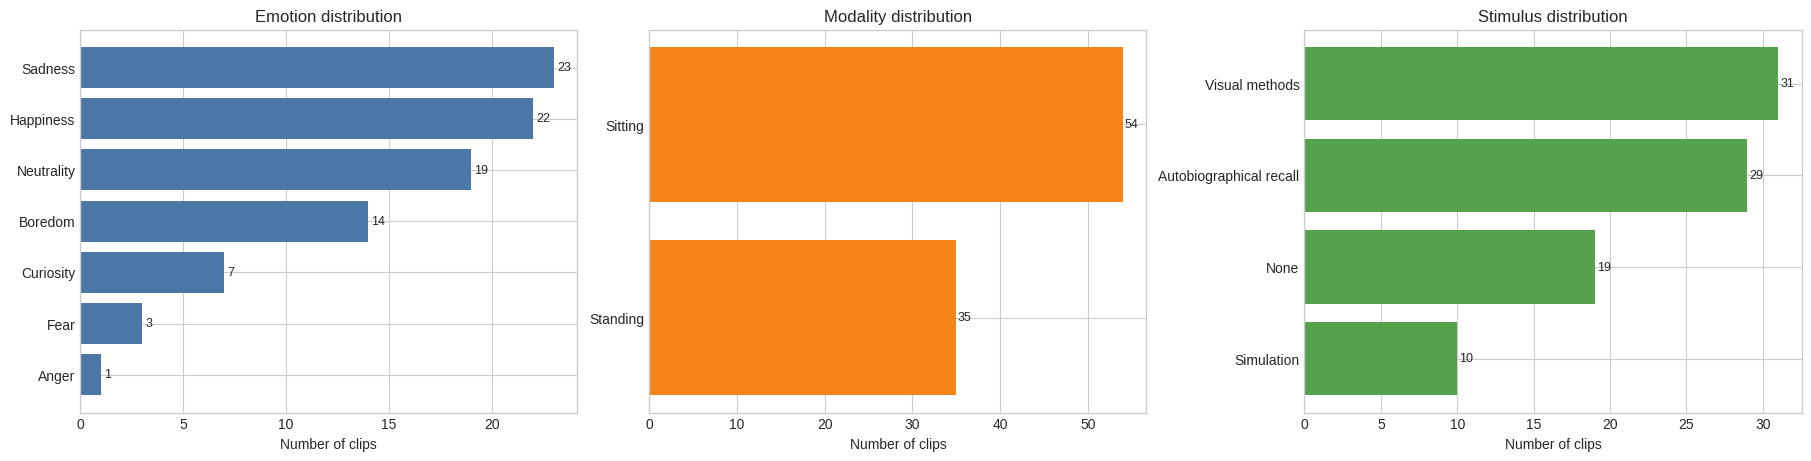

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), constrained_layout=True)

palette = {
    "emotion": "#4C78A8",
    "modality": "#F58518",
    "stimulus": "#54A24B",
}

for ax, label in zip(axes, LABEL_COLUMNS, strict=False):
    table = distribution_table(clips_df, label)
    ax.barh(table[label], table["count"], color=palette[label])
    ax.set_title(f"{label.title()} distribution")
    ax.set_xlabel("Number of clips")
    ax.invert_yaxis()
    add_value_labels(ax)

plt.show()

## Per-Domain Distribution

The next view separates `10ms` and `30ms` to show whether imbalance comes from the protocol itself or from one domain being more complete than the other.

In [6]:
domain_distribution = (
    clips_df.groupby(["domain", *LABEL_COLUMNS]).size().rename("count").reset_index()
)

emotion_by_domain = clips_df.groupby(["domain", "emotion"]).size().unstack(fill_value=0)
modality_by_domain = clips_df.groupby(["domain", "modality"]).size().unstack(fill_value=0)
stimulus_by_domain = clips_df.groupby(["domain", "stimulus"]).size().unstack(fill_value=0)

emotion_by_domain

emotion,Anger,Boredom,Curiosity,Fear,Happiness,Neutrality,Sadness
domain,,,,,,,
10ms,0,8,4,0,9,6,9
30ms,1,6,3,3,13,13,14


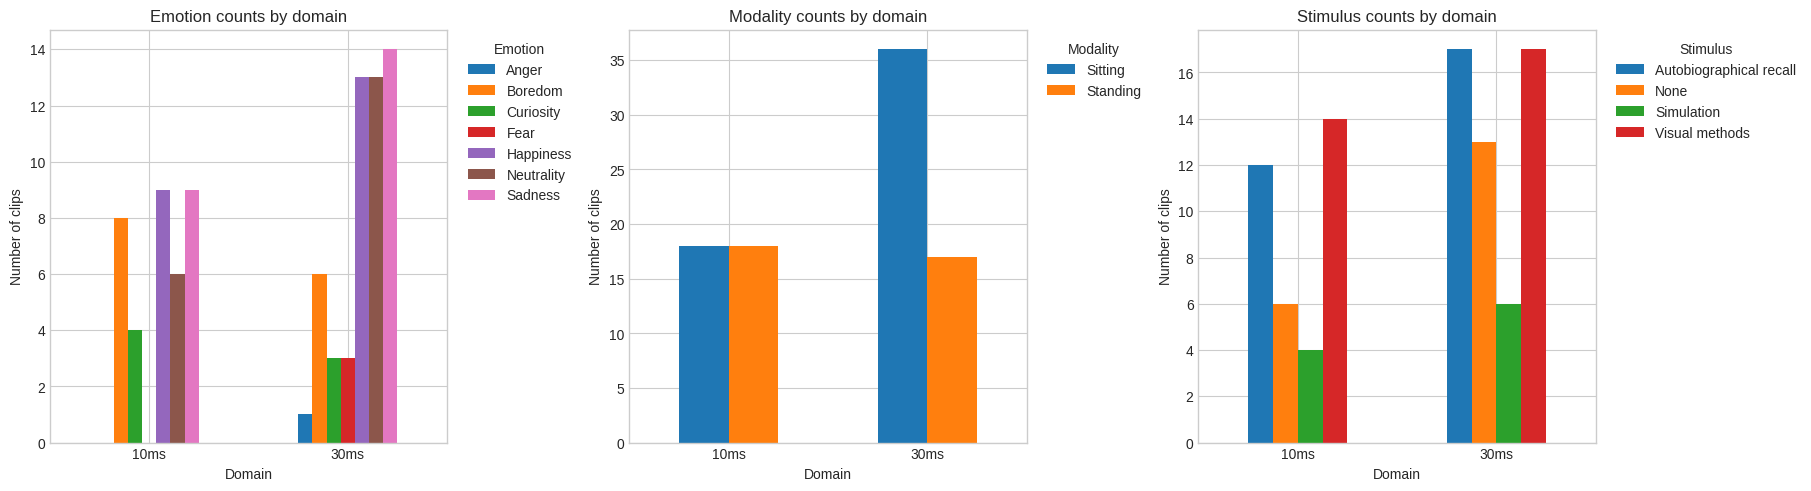

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)

for ax, label, table in zip(
    axes,
    LABEL_COLUMNS,
    (emotion_by_domain, modality_by_domain, stimulus_by_domain),
    strict=False,
):
    table.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(f"{label.title()} counts by domain")
    ax.set_xlabel("Domain")
    ax.set_ylabel("Number of clips")
    ax.legend(title=label.title(), bbox_to_anchor=(1.02, 1.0), loc="upper left")

plt.show()

## Label Co-Occurrence

These cross-tabs help reveal whether specific emotions appear only with a narrow subset of modalities or stimuli.

In [8]:
emotion_modality = pd.crosstab(clips_df["emotion"], clips_df["modality"])
emotion_stimulus = pd.crosstab(clips_df["emotion"], clips_df["stimulus"])

emotion_modality

modality,Sitting,Standing
emotion,,
Anger,0,1
Boredom,8,6
Curiosity,0,7
Fear,3,0
Happiness,17,5
Neutrality,9,10
Sadness,17,6


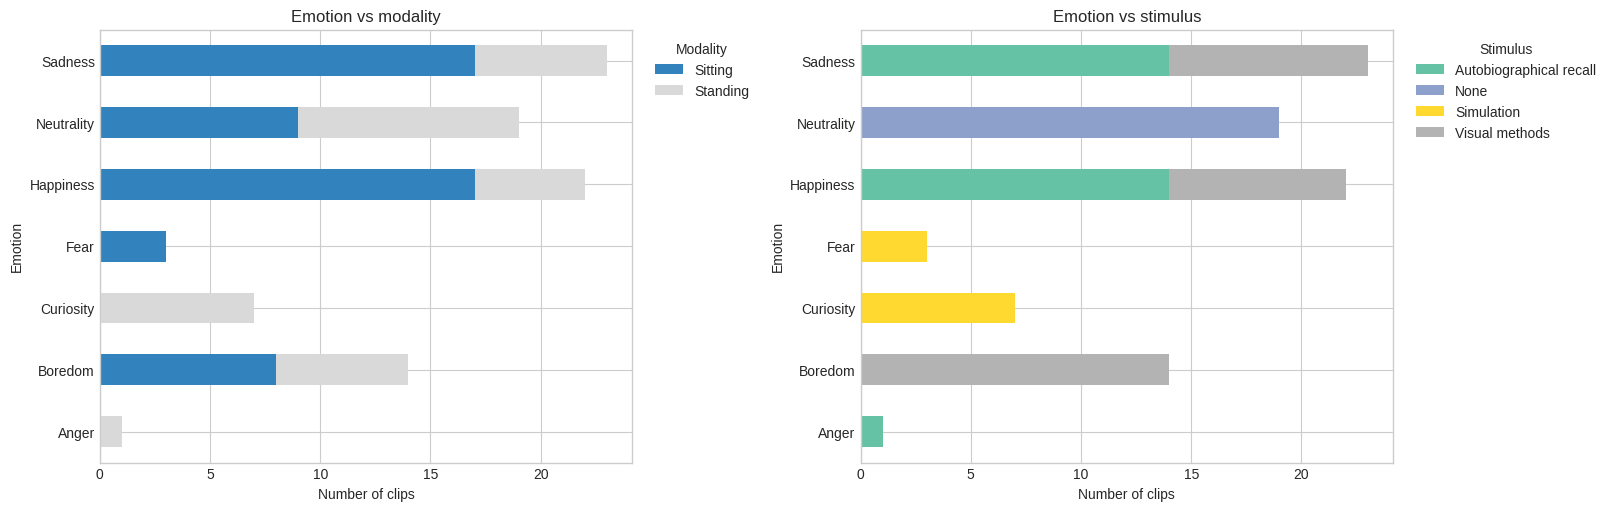

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

emotion_modality.plot(kind="barh", stacked=True, ax=axes[0], colormap="tab20c")
axes[0].set_title("Emotion vs modality")
axes[0].set_xlabel("Number of clips")
axes[0].set_ylabel("Emotion")
axes[0].legend(title="Modality", bbox_to_anchor=(1.02, 1.0), loc="upper left")

emotion_stimulus.plot(kind="barh", stacked=True, ax=axes[1], colormap="Set2")
axes[1].set_title("Emotion vs stimulus")
axes[1].set_xlabel("Number of clips")
axes[1].set_ylabel("Emotion")
axes[1].legend(title="Stimulus", bbox_to_anchor=(1.02, 1.0), loc="upper left")

plt.show()

## Protocol Coverage vs Observed Clips

The metadata file defines protocol tags for each domain, but the files available on disk do not necessarily cover every protocol row. This section compares the protocol table with the actual dataset scan.

That distinction matters because an imbalanced class histogram can come from two different causes:
- the protocol itself contains fewer tags for a class
- the local copy of the dataset is missing some tags entirely

In [10]:
protocol_rows = []
for domain in ("10ms", "30ms"):
    tag_key = f"tag_{domain}"
    for row in PROTOCOL_ROWS:
        tag_number = row.get(tag_key)
        if tag_number is None:
            continue
        protocol_rows.append(
            {
                "domain": domain,
                "tag_number": int(tag_number),
                "emotion": row.get("emotion"),
                "modality": row.get("modality"),
                "stimulus": row.get("stimulus"),
            }
        )

protocol_df = pd.DataFrame(protocol_rows)
observed_counts = (
    clips_df.groupby(["domain", "tag_number"]).size().rename("num_clips").reset_index()
)
coverage_df = protocol_df.merge(observed_counts, on=["domain", "tag_number"], how="left")
coverage_df["num_clips"] = coverage_df["num_clips"].fillna(0).astype(int)
coverage_df["present_on_disk"] = coverage_df["num_clips"] > 0

coverage_summary = (
    coverage_df.groupby("domain")["present_on_disk"]
    .agg(protocol_tags="count", covered_tags="sum")
    .assign(missing_tags=lambda frame: frame["protocol_tags"] - frame["covered_tags"])
)

coverage_summary

,protocol_tags,covered_tags,missing_tags
domain,,,
10ms,17,11,6
30ms,18,13,5


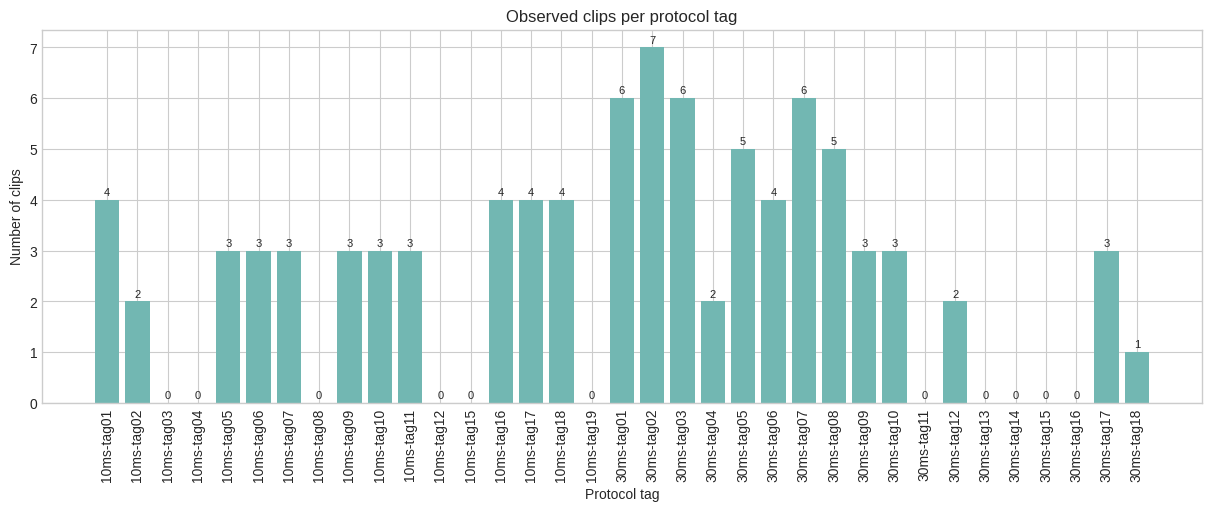

,domain,tag_number,emotion,modality,stimulus
2,10ms,3,Neutrality,Walking,None
3,10ms,4,Sadness,Walking,Music
7,10ms,8,Happiness,Walking,Music
11,10ms,12,Anger,Standing,Autobiographical recall
12,10ms,15,Fear,Running,Simulation
16,10ms,19,Curiosity,Standing,Simulation
34,30ms,11,Curiosity,Standing,Simulation
30,30ms,13,Fear,Running,Simulation
19,30ms,14,Neutrality,Walking,None
20,30ms,15,Sadness,Walking,Music


In [11]:
missing_protocol_tags = coverage_df.loc[
    ~coverage_df["present_on_disk"],
    ["domain", "tag_number", "emotion", "modality", "stimulus"],
].sort_values(["domain", "tag_number"], kind="stable")

observed_protocol_tags = coverage_df.loc[
    coverage_df["present_on_disk"],
    ["domain", "tag_number", "emotion", "modality", "stimulus", "num_clips"],
].sort_values(["domain", "tag_number"], kind="stable")

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
plot_table = coverage_df.copy().sort_values(["domain", "tag_number"], kind="stable")
colors = np.where(plot_table["present_on_disk"], "#72B7B2", "#E45756")
x_labels = plot_table.apply(lambda row: f"{row['domain']}-tag{int(row['tag_number']):02d}", axis=1)
ax.bar(x_labels, plot_table["num_clips"], color=colors)
ax.set_title("Observed clips per protocol tag")
ax.set_ylabel("Number of clips")
ax.set_xlabel("Protocol tag")
ax.tick_params(axis="x", rotation=90)

for idx, value in enumerate(plot_table["num_clips"]):
    ax.text(idx, value + 0.05, str(int(value)), ha="center", va="bottom", fontsize=8)

plt.show()

missing_protocol_tags

## Quick Findings

This cell turns the most important observations into a short textual summary.

In [12]:
emotion_counts = distribution_table(clips_df, "emotion")
modality_counts = distribution_table(clips_df, "modality")
stimulus_counts = distribution_table(clips_df, "stimulus")

observed_modalities = sorted(clips_df["modality"].dropna().unique().tolist())
protocol_modalities = sorted(protocol_df["modality"].dropna().unique().tolist())
missing_modalities = sorted(set(protocol_modalities) - set(observed_modalities))

rarest_emotion = emotion_counts.sort_values(["count", "emotion"], kind="stable").iloc[0]
largest_emotion = emotion_counts.sort_values(["count", "emotion"], ascending=[False, True], kind="stable").iloc[0]

lines = [
    f"Scanned {len(clips_df)} clips across {clips_df['domain'].nunique()} domains and {clips_df[['domain', 'user_id']].drop_duplicates().shape[0]} domain/user pairs.",
    f"Emotion is the most imbalanced label type: {largest_emotion['emotion']} is the largest class with {int(largest_emotion['count'])} clips, while {rarest_emotion['emotion']} is the smallest with {int(rarest_emotion['count'])} clip(s).",
    f"Observed modalities on disk: {', '.join(observed_modalities)}.",
    f"Modalities defined in metadata but not observed in the scanned files: {', '.join(missing_modalities) if missing_modalities else 'none'}.",
    f"Missing protocol tags: {int((~coverage_df['present_on_disk']).sum())} out of {int(len(coverage_df))} defined domain/tag combinations.",
    f"Extra repeated takes are limited: {int(clips_df['take_id'].notna().sum())} clip(s) have a non-null take id.",
]

print("\n".join(f"- {line}" for line in lines))

- Scanned 89 clips across 2 domains and 11 domain/user pairs.
- Emotion is the most imbalanced label type: Sadness is the largest class with 23 clips, while Anger is the smallest with 1 clip(s).
- Observed modalities on disk: Sitting, Standing.
- Modalities defined in metadata but not observed in the scanned files: Running, Walking.
- Missing protocol tags: 11 out of 35 defined domain/tag combinations.
- Extra repeated takes are limited: 2 clip(s) have a non-null take id.
